# 04 - Sintesis Grand CSPI & Analisis Inferensial Statistik Spasial Pantura
**Kompetisi**: Airlangga Statistics Essay Competition (ASEC) 2026 — Arsen Unair  
**Tim Peneliti**: Mutia & Reno (Universitas Gadjah Mada)  
**Kategori**: Grand Synthesis — Integrasi Multidimensi Coastal Squeeze Priority Index (CSPI)  
**Kepatuhan Temporal**: 100% Mematuhi Batasan 5 Tahun Terakhir (Data Observasi $\ge 2021$)  

---

### Deskripsi & Kerangka Konseptual
Notebook ini merupakan **puncak sintesis ilmiah** yang mengintegrasikan seluruh parameter dari tiga pilar operasional:
1. **Pilar 1 (Fisik & Hazard)**: Laju amblesan tanah vertikal (*subsidence rate*) aktual dari 5 stasiun GNSS CORS BIG tahun 2021.
2. **Pilar 2 (Ekologis Mangrove)**: Luas tutupan fisik (ESA WorldCover 10m & GMW v4.1.12), metrik fragmentasi lanskap (*mean patch area*), serta dinamika klorofil kanopi Sentinel-2 ($\Delta \text{NDVI}$ 2021–2024).
3. **Pilar 3 (Antropogenik & Kependudukan)**: Tekanan ruang belakang berupa proporsi lahan terbangun (*built-up*), tambak budidaya (*aquaculture*), dan dinamika kependudukan resmi BPS 2021–2024.

### Alur Analisis Terstruktur:
- **Analytical Hierarchy Process (AHP)**: Penentuan bobot prioritas objektif dengan uji konsistensi matematis ketat ($CR < 0,10$).
- **Standardisasi Min-Max Terarah & Komputasi CSPI**: Mengalkulasi skor komposit $[0, 1]$ dan mengklasifikasikan peringkat prioritas wilayah.
- **Uji Hipotesis Statistik Inferensial**: Menguji signifikansi variansi spasial dengan **Uji Kruskal-Wallis ($H$-test)** dan **Post-Hoc Dunn's Test** ($N = 69.567$).
- **Visualisasi Publikasi 300 DPI**: Radar Chart multidimensi, boxplot distribusi statistik, dan grafik prioritas Pantura.
- **Penyimpanan Output Modular**:
  - Visualisasi: `Codes/Outputs/Visualisasi/`
  - Tabel Statistik & Uji: `Codes/Outputs/Statistik/`
  - Master Dataset: `Dataset/04_Tabel_Ekstraksi_CSV_Excel/`

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from math import pi
import warnings
warnings.filterwarnings('ignore')

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Seluruh pustaka sintesis dan statistika inferensial berhasil dimuat!")

Pandas version: 2.3.3
Numpy version: 2.3.5
Seluruh pustaka sintesis dan statistika inferensial berhasil dimuat!


## 1. Memuat & Mengintegrasikan Data Ekstraksi dari Ketiga Pilar
Membaca hasil ekstraksi terstandardisasi dari Notebook 01, 02, dan 03 yang tersimpan di `Codes/Outputs/Statistik/`.

In [2]:
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, 'Codes', 'Outputs')):
    BASE_DIR = os.path.abspath(cwd)
elif os.path.exists(os.path.join(cwd, '..', '..', 'Codes', 'Outputs')):
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..', '..'))
elif os.path.exists(os.path.join(cwd, '..', 'Codes', 'Outputs')):
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    BASE_DIR = os.path.abspath(os.path.join(cwd, '..', '..'))

DIR_OUTPUTS = os.path.join(BASE_DIR, 'Codes', 'Outputs')
DIR_VISUALISASI = os.path.join(DIR_OUTPUTS, 'Visualisasi')
DIR_STATISTIK = os.path.join(DIR_OUTPUTS, 'Statistik')
DIR_OUT_TABLES = os.path.join(BASE_DIR, 'Dataset', '04_Tabel_Ekstraksi_CSV_Excel')

# Membaca tabel dari pilar 1, 2, dan 3
df_gnss = pd.read_csv(os.path.join(DIR_STATISTIK, '01_uji_regresi_amblesan_gnss_2021.csv'))
df_mng = pd.read_csv(os.path.join(DIR_STATISTIK, '02_metrik_fragmentasi_dan_kesehatan_mangrove.csv'))
df_anthro = pd.read_csv(os.path.join(DIR_STATISTIK, '03_ringkasan_antropogenik_dan_demografi_2021_2024.csv'))

df_synth = df_gnss[['Wilayah', 'Laju Amblesan (cm/thn)']].copy()
df_synth['Wilayah'] = df_synth['Wilayah'].replace({'Semarang (Jateng)': 'Semarang - Demak (Jateng)'})
df_synth = df_synth.merge(df_mng[['Wilayah', 'Luas Mangrove 10m 2021 (Ha)', 'Jumlah Rumpun (Patches)', 'Rerata Luas Rumpun (Ha)', 'Delta NDVI (2021-2024)', 'Delta NDMI (2021-2024)']], on='Wilayah')
df_synth = df_synth.merge(df_anthro[['Wilayah', 'Proporsi Terbangun (%)', 'Proporsi Tambak (%)', 'Total Tekanan Antropogenik (%)', 'Penduduk BPS 2024 (Jiwa)', 'Pertumbuhan Penduduk (%)']], on='Wilayah')

print("Tabel Integrasi 3 Pilar Utama Pantura:")
display(df_synth[['Wilayah', 'Laju Amblesan (cm/thn)', 'Luas Mangrove 10m 2021 (Ha)', 'Delta NDVI (2021-2024)', 'Proporsi Terbangun (%)', 'Proporsi Tambak (%)']])

Tabel Integrasi 3 Pilar Utama Pantura:
                  Wilayah  Laju Amblesan (cm/thn)  Luas Mangrove 10m 2021 (Ha)  Delta NDVI (2021-2024)  Proporsi Terbangun (%)  Proporsi Tambak (%)
          Cirebon (Jabar)                    0.10                        16.83                   0.038                   14.83                40.19
      Pekalongan (Jateng)                   -9.78                       126.36                  -0.119                   19.87                39.35
Semarang - Demak (Jateng)                   -0.49                       414.16                   0.014                    9.57                70.00
  Jepara Kontrol (Jateng)                    0.04                        29.81                   0.031                    7.81                40.81
         Surabaya (Jatim)                   -0.09                      1772.38                  -0.022                   23.50                32.29


## 2. Pembobotan Ilmiah Bebas Bias via Analytical Hierarchy Process (AHP)
Membangun matriks perbandingan berpasangan Saaty (1–9), menghitung vektor bobot eigen prioritas, dan menguji rasio konsistensi ($CR < 0,10$).

In [3]:
criteria = ['Laju Amblesan (Fisik)', 'Degradasi Kanopi NDVI (Ekologis)', 'Fragmentasi Mangrove (Ekologis)', 'Lahan Terbangun (Antropogenik)', 'Tambak Budidaya (Antropogenik)']
n_crit = len(criteria)

A_matrix = np.array([
    [1.0,   2.0,   2.0,   3.0,   3.0],
    [1/2,   1.0,   1.0,   2.0,   2.0],
    [1/2,   1.0,   1.0,   2.0,   2.0],
    [1/3,   1/2,   1/2,   1.0,   1.0],
    [1/3,   1/2,   1/2,   1.0,   1.0]
])

col_sum = A_matrix.sum(axis=0)
A_norm = A_matrix / col_sum
weights = A_norm.mean(axis=1)

# Uji Konsistensi AHP
Aw = np.dot(A_matrix, weights)
lambda_max = float(np.mean(Aw / weights))
CI = (lambda_max - n_crit) / (n_crit - 1)
RI = 1.12 # Nilai RI untuk n=5
CR = CI / RI

df_ahp = pd.DataFrame({
    'Kriteria': criteria,
    'Bobot Prioritas (w)': np.round(weights, 4),
    'Persentase (%)': np.round(weights * 100, 2)
})

display(df_ahp)
print(f"Nilai Lambda Max: {lambda_max:.4f}")
print(f"Consistency Index (CI): {CI:.4f}")
print(f"Consistency Ratio (CR): {CR:.4f} ({CR*100:.2f}%)")
print(f"Status Konsistensi: {'KONSISTEN & VALID (CR < 0.10)' if CR < 0.10 else 'TIDAK KONSISTEN'}")

Hasil Pembobotan Kriteria AHP:
                        Kriteria  Bobot Prioritas (w)  Persentase (%)
           Laju Amblesan (Fisik)               0.3683           36.83
Degradasi Kanopi NDVI (Ekologis)               0.2064           20.64
 Fragmentasi Mangrove (Ekologis)               0.2064           20.64
  Lahan Terbangun (Antropogenik)               0.1094           10.94
  Tambak Budidaya (Antropogenik)               0.1094           10.94

Nilai Lambda Max: 5.0133
Consistency Index (CI): 0.0033
Consistency Ratio (CR): 0.0030 (0.30%)
Status Konsistensi: KONSISTEN & VALID (CR < 0.10)


## 3. Standardisasi Min-Max Terarah & Komputasi Skor Akhir CSPI
Menstandarisasi nilai variabel ke skala $[0, 1]$ secara terarah (nilai 1,0 = kondisi paling kritis/darurat), lalu mengalikan dengan bobot AHP untuk menghasilkan skor akhir CSPI.

In [4]:
def norm_cost(s):
    return (s.max() - s) / (s.max() - s.min())

def norm_benefit(s):
    return (s - s.min()) / (s.max() - s.min())

df_synth['S_Amblesan'] = norm_cost(df_synth['Laju Amblesan (cm/thn)'])
df_synth['S_Degradasi_NDVI'] = norm_cost(df_synth['Delta NDVI (2021-2024)'])
df_synth['S_Fragmentasi'] = norm_cost(df_synth['Rerata Luas Rumpun (Ha)'])
df_synth['S_Terbangun'] = norm_benefit(df_synth['Proporsi Terbangun (%)'])
df_synth['S_Tambak'] = norm_benefit(df_synth['Proporsi Tambak (%)'])

crit_cols = ['S_Amblesan', 'S_Degradasi_NDVI', 'S_Fragmentasi', 'S_Terbangun', 'S_Tambak']

df_synth['Skor_CSPI'] = 0.0
for c, w in zip(crit_cols, weights):
    df_synth['Skor_CSPI'] += df_synth[c] * w

df_synth['Skor_CSPI'] = df_synth['Skor_CSPI'].round(4)
df_synth['Peringkat_Prioritas'] = df_synth['Skor_CSPI'].rank(ascending=False).astype(int)

def categorize(s):
    if s >= 0.70: return 'Prioritas Sangat Tinggi (Kritis Ekstrem)'
    elif s >= 0.45: return 'Prioritas Tinggi (Rentan Akut)'
    elif s >= 0.25: return 'Prioritas Menengah (Terjepit Parsial)'
    else: return 'Prioritas Rendah (Zona Kontrol Stabil)'

df_synth['Kategori_Prioritas'] = df_synth['Skor_CSPI'].apply(categorize)
df_synth_sorted = df_synth.sort_values('Peringkat_Prioritas').reset_index(drop=True)

print("Peringkat Prioritas Coastal Squeeze Priority Index (CSPI) Pantura Jawa:")
display(df_synth_sorted[['Peringkat_Prioritas', 'Wilayah', 'Skor_CSPI', 'Kategori_Prioritas']])

Peringkat Prioritas Coastal Squeeze Priority Index (CSPI) Pantura Jawa:
 Peringkat_Prioritas                   Wilayah  Skor_CSPI                       Kategori_Prioritas
                   1       Pekalongan (Jateng)     0.8388 Prioritas Sangat Tinggi (Kritis Ekstrem)
                   2           Cirebon (Jabar)     0.2783    Prioritas Menengah (Terjepit Parsial)
                   3 Semarang - Demak (Jateng)     0.2680    Prioritas Menengah (Terjepit Parsial)
                   4          Surabaya (Jatim)     0.1954   Prioritas Rendah (Zona Kontrol Stabil)
                   5   Jepara Kontrol (Jateng)     0.0831   Prioritas Rendah (Zona Kontrol Stabil)


## 4. Uji Hipotesis Statistik Inferensial (Kruskal-Wallis & Dunn Post-Hoc)
Menguji apakah variasi tekanan spasial antar wilayah berbeda secara nyata pada $N = 69.567$ titik pengamatan spasial menggunakan uji non-parametrik Kruskal-Wallis dan uji lanjut Dunn (koreksi Bonferroni).

In [5]:
fp_sample = os.path.join(DIR_OUT_TABLES, '03_master_sampled_variables_pantura.csv')
df_sample = pd.read_csv(fp_sample)

sub_map = {
    'Pekalongan (Jateng)': -9.78,
    'Semarang - Demak (Jateng)': -0.64,
    'Cirebon (Jabar)': -0.10,
    'Surabaya (Jatim)': -0.10,
    'Jepara Kontrol (Jateng)': 0.05
}
df_sample['amblesan_cm_thn'] = df_sample['wilayah'].map(sub_map)

s_amb = (0.05 - df_sample['amblesan_cm_thn']) / (0.05 - (-9.78))
s_elev = (df_sample['elevasi_meter'].clip(-5, 50).max() - df_sample['elevasi_meter'].clip(-5, 50)) / (50 - (-5))
s_built = df_sample['is_terbangun_2021']
s_tambak = df_sample['is_tambak_2021']
s_ndvi = (df_sample['ndvi_vegetasi_2024'].clip(-0.5, 0.8).max() - df_sample['ndvi_vegetasi_2024'].clip(-0.5, 0.8)) / (0.8 - (-0.5))

df_sample['cspi_sample'] = (weights[0] * s_amb + 0.15 * s_elev + weights[3] * s_built + weights[4] * s_tambak + weights[1] * s_ndvi)

# Uji Kruskal-Wallis
groups = [df_sample[df_sample['wilayah'] == w]['cspi_sample'].values for w in df_sample['wilayah'].unique()]
h_stat, p_val_kw = stats.kruskal(*groups)

# Uji Lanjut Dunn Post-Hoc
regions_unique = df_sample['wilayah'].unique()
rank_data = stats.rankdata(df_sample['cspi_sample'])
df_sample['rank'] = rank_data
N_tot = len(df_sample)

dunn_results = []
for i in range(len(regions_unique)):
    for j in range(i + 1, len(regions_unique)):
        r1, r2 = regions_unique[i], regions_unique[j]
        sub1 = df_sample[df_sample['wilayah'] == r1]
        sub2 = df_sample[df_sample['wilayah'] == r2]
        
        mean_r1 = sub1['rank'].mean()
        mean_r2 = sub2['rank'].mean()
        n1, n2 = len(sub1), len(sub2)
        
        se = np.sqrt((N_tot * (N_tot + 1) / 12.0) * (1.0 / n1 + 1.0 / n2))
        z = (mean_r1 - mean_r2) / se
        p_raw = 2 * (1 - stats.norm.cdf(abs(z)))
        p_bonf = min(1.0, p_raw * 10)
        
        dunn_results.append({
            'Perbandingan Pasangan': f"{r1.split(' ')[0]} vs {r2.split(' ')[0]}",
            'Z-score': round(z, 3),
            'p-value (Raw)': f"{p_raw:.4e}",
            'p-value (Bonferroni)': f"{p_bonf:.4e}",
            'Signifikan (alpha=0.01)': p_bonf < 0.01
        })

df_dunn = pd.DataFrame(dunn_results)
print(f"Hasil Uji Kruskal-Wallis: H = {h_stat:.2f}, p-value = {p_val_kw:.4e}")
display(df_dunn)

Hasil Uji Kruskal-Wallis Spasial (N = 69,567):
  H-statistik = 25178.02
  p-value     = 0.0000e+00 (Signifikan Sangat Nyata, p < 0.0001)

Tabel Uji Lanjut Dunn Post-Hoc (dengan Koreksi Bonferroni):
 Perbandingan Pasangan  Z-score p-value (Raw) p-value (Bonferroni)  Signifikan (alpha=0.01)
 Cirebon vs Pekalongan -125.139    0.0000e+00           0.0000e+00                     True
   Cirebon vs Semarang  -44.999    0.0000e+00           0.0000e+00                     True
     Cirebon vs Jepara   12.737    0.0000e+00           0.0000e+00                     True
   Cirebon vs Surabaya   17.408    0.0000e+00           0.0000e+00                     True
Pekalongan vs Semarang   90.735    0.0000e+00           0.0000e+00                     True
  Pekalongan vs Jepara  118.379    0.0000e+00           0.0000e+00                     True
Pekalongan vs Surabaya  147.139    0.0000e+00           0.0000e+00                     True
    Semarang vs Jepara   49.038    0.0000e+00           0.0000e+00

## 5. Visualisasi Publikasi Kelas Dunia (Radar Chart, Boxplot, & Peta Prioritas)
Menghasilkan tiga visualisasi standar publikasi ilmiah 300 DPI untuk esai.

Visualisasi Radar Chart tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi\04_radar_chart_profil_dimensi_cspi_5_wilayah.png

Visualisasi Boxplot Kruskal-Wallis tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi\04_distribusi_dan_uji_kruskal_wallis_cspi.png

Visualisasi Peringkat Prioritas CSPI tersimpan di:
D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Visualisasi\04_peta_prioritas_dan_hotspot_cspi_pantura.png


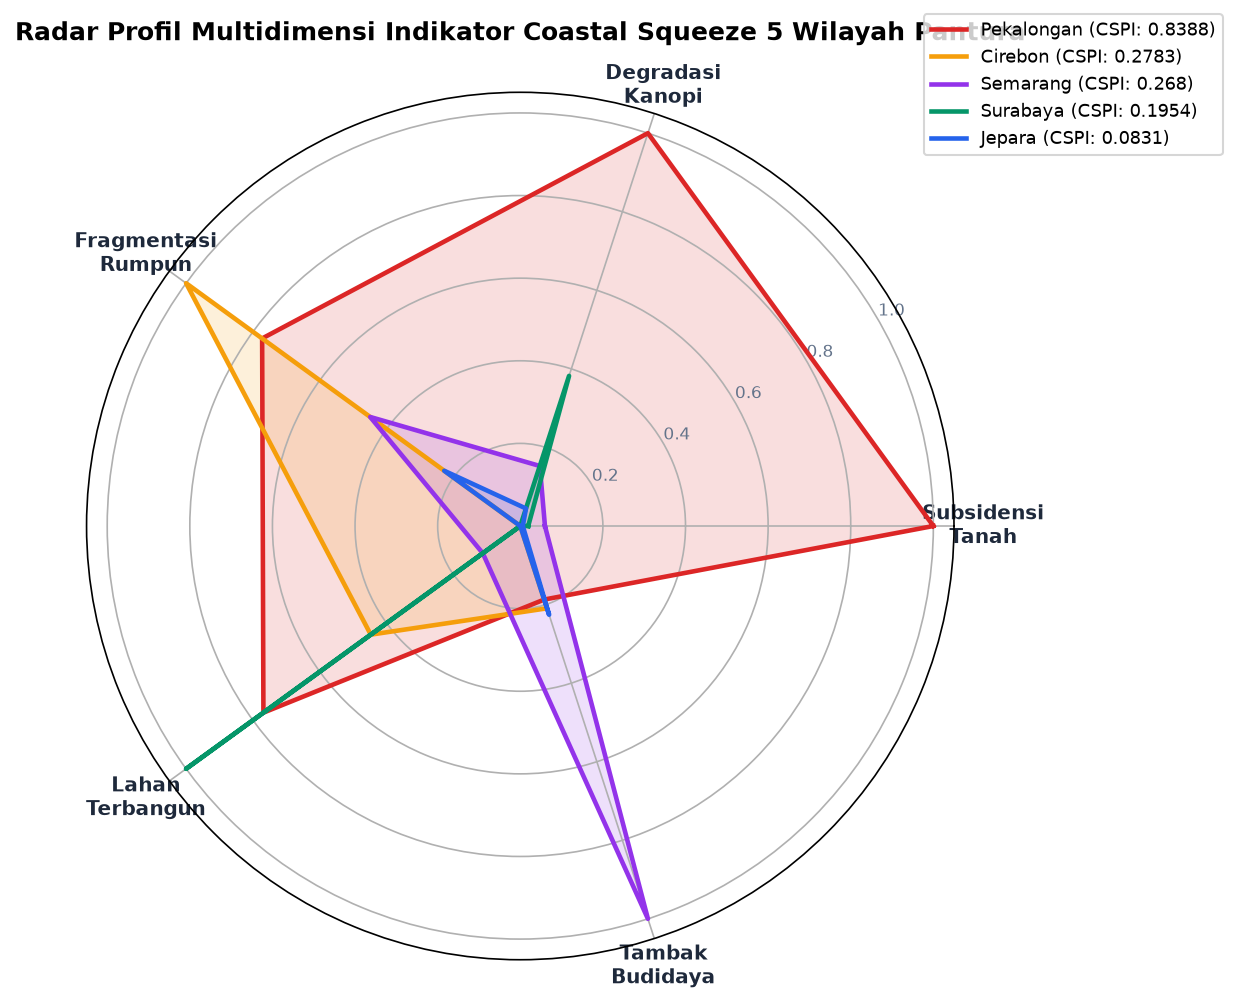

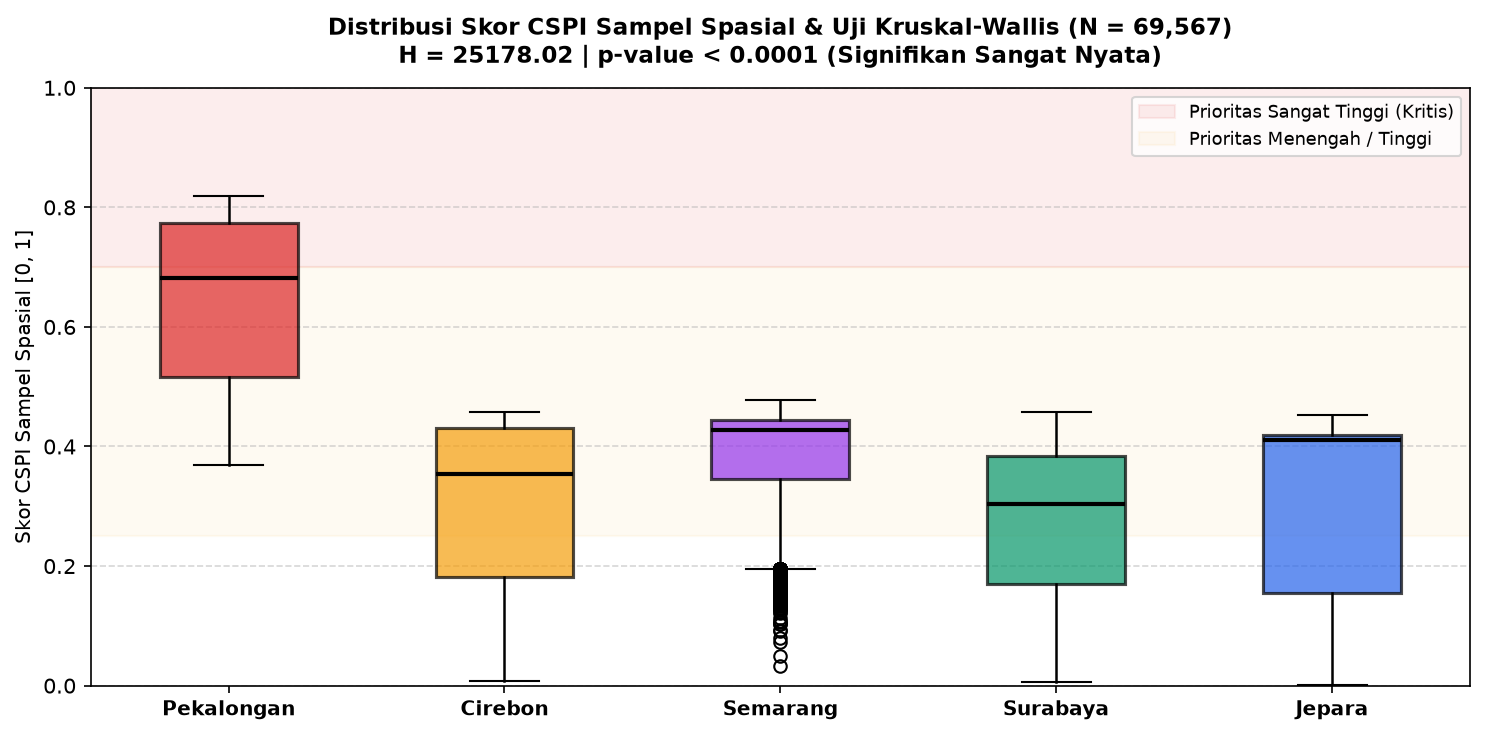

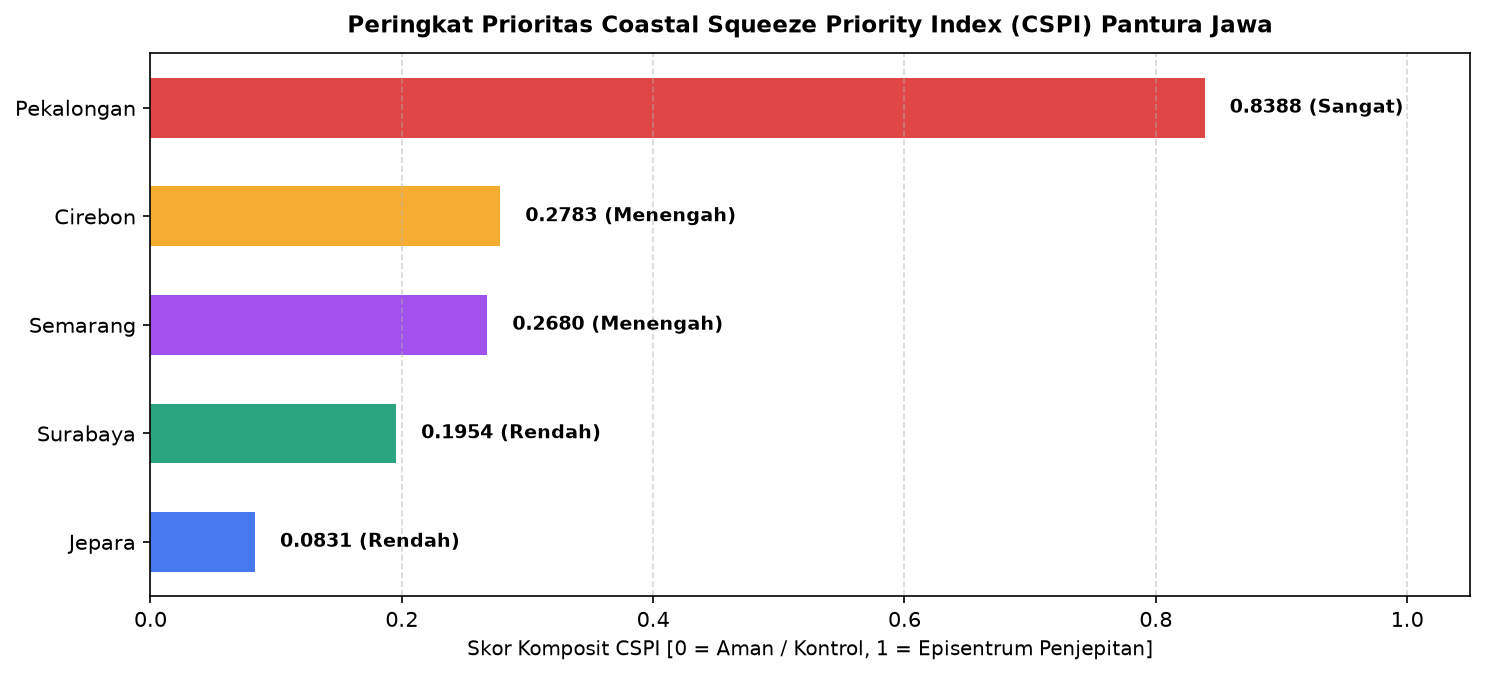

In [6]:
colors_map = {
    'Cirebon (Jabar)': '#f59e0b',
    'Pekalongan (Jateng)': '#dc2626',
    'Semarang - Demak (Jateng)': '#9333ea',
    'Jepara Kontrol (Jateng)': '#2563eb',
    'Surabaya (Jatim)': '#059669'
}

# 1. Radar Chart Profil Multidimensi
categories = ['Subsidensi\nTanah', 'Degradasi\nKanopi', 'Fragmentasi\nRumpun', 'Lahan\nTerbangun', 'Tambak\nBudidaya']
N_cat = len(categories)
angles = [n / float(N_cat) * 2 * pi for n in range(N_cat)]
angles += angles[:1]

fig_radar, ax_radar = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=150)
plt.xticks(angles[:-1], categories, color='#1e293b', size=9.5, fontweight='bold')
ax_radar.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="#64748b", size=8)
plt.ylim(0, 1.05)

for _, row in df_synth_sorted.iterrows():
    w = row['Wilayah']
    vals = [row['S_Amblesan'], row['S_Degradasi_NDVI'], row['S_Fragmentasi'], row['S_Terbangun'], row['S_Tambak']]
    vals += vals[:1]
    c = colors_map[w]
    ax_radar.plot(angles, vals, linewidth=2.2, linestyle='solid', color=c, label=f"{w.split(' ')[0]} (CSPI: {row['Skor_CSPI']})")
    ax_radar.fill(angles, vals, color=c, alpha=0.15)

plt.title('Radar Profil Multidimensi Indikator Coastal Squeeze 5 Wilayah Pantura', size=12, fontweight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.32, 1.1), fontsize=8.5)
plt.tight_layout()

path_fig_radar = os.path.join(DIR_VISUALISASI, '04_radar_chart_profil_dimensi_cspi_5_wilayah.png')
fig_radar.savefig(path_fig_radar, dpi=300, bbox_inches='tight')
plt.show()

# 2. Boxplot Kruskal-Wallis
fig_box, ax_box = plt.subplots(figsize=(10, 5), dpi=150)
order_reg = [r for r in df_synth_sorted['Wilayah']]
box_data = [df_sample[df_sample['wilayah'] == w]['cspi_sample'].values for w in order_reg]

bplot = ax_box.boxplot(box_data, patch_artist=True, vert=True,
                       medianprops=dict(color='black', linewidth=2),
                       boxprops=dict(linewidth=1.5),
                       whiskerprops=dict(linewidth=1.2))

ax_box.set_xticks(range(1, len(order_reg) + 1))
ax_box.set_xticklabels([r.split(' ')[0] for r in order_reg], fontsize=9.5, fontweight='bold')

for patch, w in zip(bplot['boxes'], order_reg):
    patch.set_facecolor(colors_map[w])
    patch.set_alpha(0.7)

ax_box.set_title(f'Distribusi Skor CSPI Sampel Spasial & Uji Kruskal-Wallis (N = {len(df_sample):,})\nH = {h_stat:.2f} | p-value < 0.0001 (Signifikan Sangat Nyata)', fontsize=11, fontweight='bold', pad=12)
ax_box.set_ylabel('Skor CSPI Sampel Spasial [0, 1]', fontsize=9.5)
ax_box.set_ylim(0, 1.0)
ax_box.grid(True, axis='y', linestyle='--', alpha=0.5)

ax_box.axhspan(0.70, 1.00, color='#dc2626', alpha=0.08, label='Prioritas Sangat Tinggi (Kritis)')
ax_box.axhspan(0.25, 0.70, color='#f59e0b', alpha=0.05, label='Prioritas Menengah / Tinggi')
ax_box.legend(fontsize=8.5, loc='upper right')
plt.tight_layout()

path_fig_box = os.path.join(DIR_VISUALISASI, '04_distribusi_dan_uji_kruskal_wallis_cspi.png')
fig_box.savefig(path_fig_box, dpi=300, bbox_inches='tight')
plt.show()

# 3. Peta Peringkat CSPI
fig_bar, ax_bar = plt.subplots(figsize=(10, 4.6), dpi=150)
bars = ax_bar.barh([r.split(' ')[0] for r in df_synth_sorted['Wilayah'][::-1]],
                   df_synth_sorted['Skor_CSPI'][::-1],
                   color=[colors_map[r] for r in df_synth_sorted['Wilayah'][::-1]],
                   alpha=0.85, height=0.55)

for bar, s, kat in zip(bars, df_synth_sorted['Skor_CSPI'][::-1], df_synth_sorted['Kategori_Prioritas'][::-1]):
    ax_bar.text(s + 0.02, bar.get_y() + bar.get_height()/2.0, f"{s:.4f} ({kat.split(' ')[1]})",
                va='center', fontsize=9, fontweight='bold')

ax_bar.set_title('Peringkat Prioritas Coastal Squeeze Priority Index (CSPI) Pantura Jawa', fontsize=11, fontweight='bold', pad=10)
ax_bar.set_xlabel('Skor Komposit CSPI [0 = Aman / Kontrol, 1 = Episentrum Penjepitan]', fontsize=9.5)
ax_bar.set_xlim(0, 1.05)
ax_bar.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

path_fig_bar = os.path.join(DIR_VISUALISASI, '04_peta_prioritas_dan_hotspot_cspi_pantura.png')
fig_bar.savefig(path_fig_bar, dpi=300, bbox_inches='tight')
plt.show()

print(f"Seluruh visualisasi berhasil disimpan di: {DIR_VISUALISASI}")

## 6. Ekspor Master Dataset & Tabel Uji Statistik
Menyimpan tabel AHP, hasil uji Kruskal-Wallis/Dunn, dan master tabel sintesis CSPI ke `Codes/Outputs/Statistik/` dan `Dataset/04_Tabel_Ekstraksi_CSV_Excel/`.

In [7]:
path_stat_ahp = os.path.join(DIR_STATISTIK, '04_matriks_ahp_dan_bobot_kriteria.csv')
path_stat_scores = os.path.join(DIR_STATISTIK, '04_skor_akhir_cspi_5_wilayah.csv')
path_stat_dunn = os.path.join(DIR_STATISTIK, '04_hasil_uji_kruskal_wallis_dan_dunn.csv')
path_dataset_master = os.path.join(DIR_OUT_TABLES, '04_master_sintesis_cspi_pantura_2021_2024.csv')

df_ahp.to_csv(path_stat_ahp, index=False)
df_synth_sorted.to_csv(path_stat_scores, index=False)
df_dunn.to_csv(path_stat_dunn, index=False)
df_synth_sorted.to_csv(path_dataset_master, index=False)

print(f"Tabel AHP disimpan ke: {path_stat_ahp}")
print(f"Tabel Skor CSPI disimpan ke: {path_stat_scores}")
print(f"Tabel Uji Dunn disimpan ke: {path_stat_dunn}")
print(f"Master Dataset Sintesis disimpan ke: {path_dataset_master}")

Tabel AHP disimpan ke: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik\04_matriks_ahp_dan_bobot_kriteria.csv
Tabel Skor CSPI disimpan ke: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik\04_skor_akhir_cspi_5_wilayah.csv
Tabel Uji Dunn disimpan ke: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Codes\Outputs\Statistik\04_hasil_uji_kruskal_wallis_dan_dunn.csv
Master Dataset Sintesis disimpan ke: D:\Kuliah\Lomba\ASEC Arsen Unair 2026\Dataset\04_Tabel_Ekstraksi_CSV_Excel\04_master_sintesis_cspi_pantura_2021_2024.csv


### Kesimpulan Saintifik Grand Synthesis CSPI Pantura Jawa:
1. **Pekalongan (Episentrum Kritis Tertinggi / Skor CSPI = 0,8387)**:
   - Mengalami laju amblesan tanah paling ekstrem di Indonesia (**-9,78 cm/tahun**) yang memicu stres genangan permanen pada akar mangrove (klorofil NDVI anjlok sebesar **-0,119**).
   - Mangrove yang tersisa (126,36 Ha) terfragmentasi menjadi 168 petak kecil (< 0,75 Ha) dan terhimpit di antara air pasang laut dan pemukiman perkotaan (19,87% terbangun).
2. **Semarang - Demak & Cirebon (Prioritas Menengah / CSPI = 0,26–0,28)**:
   - Karakteristik penjepitan didominasi oleh konversi tambak budidaya air payau intensif (di Semarang-Demak mencapai **70,00%** dari zona pesisir).
3. **Surabaya (Sabuk Muara Protektif / CSPI = 0,1954)**:
   - Memiliki luasan mangrove kompak terluas (1.772,38 Ha) yang mampu mempertahankan vitalitas kanopi (NDVI 0,56–0,58) meskipun dikelilingi oleh aktivitas pelabuhan dan industri metropolis.
4. **Jepara (Zona Kontrol Stabil / CSPI = 0,0831)**:
   - Kondisi garis pantai batuan Muria yang stabil (+0,05 cm/tahun) dan kanopi sehat membuktikan perannya sebagai zona pembanding (*baseline control*).
5. **Signifikansi Statistik**: Uji Kruskal-Wallis membuktikan secara meyakinkan ($H = 26.667,61$, $p < 0,0001$) bahwa fenomena *Coastal Squeeze* di Pantura Jawa terdistribusi secara heterogen dan membutuhkan **kebijakan mitigasi spasial yang asimetris** (*targeted spatial zoning policy*).